In [1]:
import sys
sys.path.insert(0, '../simulation')

import numpy as np
import matplotlib.pyplot as plt

from resources import (
    ResourceType,
    ResourceConfig,
    DEFAULT_RESOURCE_CONFIGS,
    sample_distribution,
)
from solar_system import Planet, SolarSystem
from buildings import BuildingType, ResourceType
from colony import Colony, Faction, DirectiveType
from snapshot import take_snapshot, plot_history

from tqdm import tqdm

R = ResourceType


In [2]:
"""
Create a faction
Spawn a system and start the faction on a Planet
Spawn the faction with a mine on the Planet
Create some basic logic to begin making buildings to expand resource collection
Continue to grow the faction until a new planet can be colonized
Colonize the new Planet
Create new planetary leads and department leads
Manage two colonies at once
"""
# --- Build a faction with two colonies ---
faction = Faction(faction_id=0, name="Test Faction")

home = Colony(
    colony_id  = 0,
    name       = "Main Colony",
    system_id  = 0,
    population = 800.0,
    stockpile  = {
        int(R.MINERALS): 2000.0,
        int(R.ENERGY):    500.0,
        int(R.ORGANICS): 8000.0,
        int(R.RARE_MATS):  20.0,
    },
)

outpost = Colony(
    colony_id  = 1,
    name       = "Outpost Colony",
    system_id  = 1,
    population = 200.0,
    stockpile  = {
        int(R.MINERALS):  500.0,
        int(R.ENERGY):    100.0,
        int(R.ORGANICS):  800.0,
        int(R.RARE_MATS):   5.0,
    },
)

faction.add_colony(home)
faction.add_colony(outpost)

# Seed some buildings
home.construct_building(BuildingType.FARM,        planet_index=0)
home.construct_building(BuildingType.MINE,        planet_index=0)
home.construct_building(BuildingType.POWER_PLANT, planet_index=0)
home.construct_building(BuildingType.LAB,         planet_index=0)
outpost.construct_building(BuildingType.FARM,     planet_index=0)

# Issue directives
faction.issue_directive(0, DirectiveType.EXPAND, tax_rate=0.15, urgency=0.7)
faction.issue_directive(1, DirectiveType.EXPAND,  tax_rate=0.05, urgency=0.8)

# Run 20 ticks
history = []
tick_number = 500
for t in range(1, tick_number + 1):
    faction.tick()
    if t == 50:
        faction.issue_directive(0, DirectiveType.IDLE, tax_rate=0.25, urgency=0.9)
        faction.issue_directive(1, DirectiveType.IDLE, tax_rate=0.25, urgency=0.9)
    history.append(take_snapshot(faction.colonies[0]))

colony_name = faction.colonies[0].name



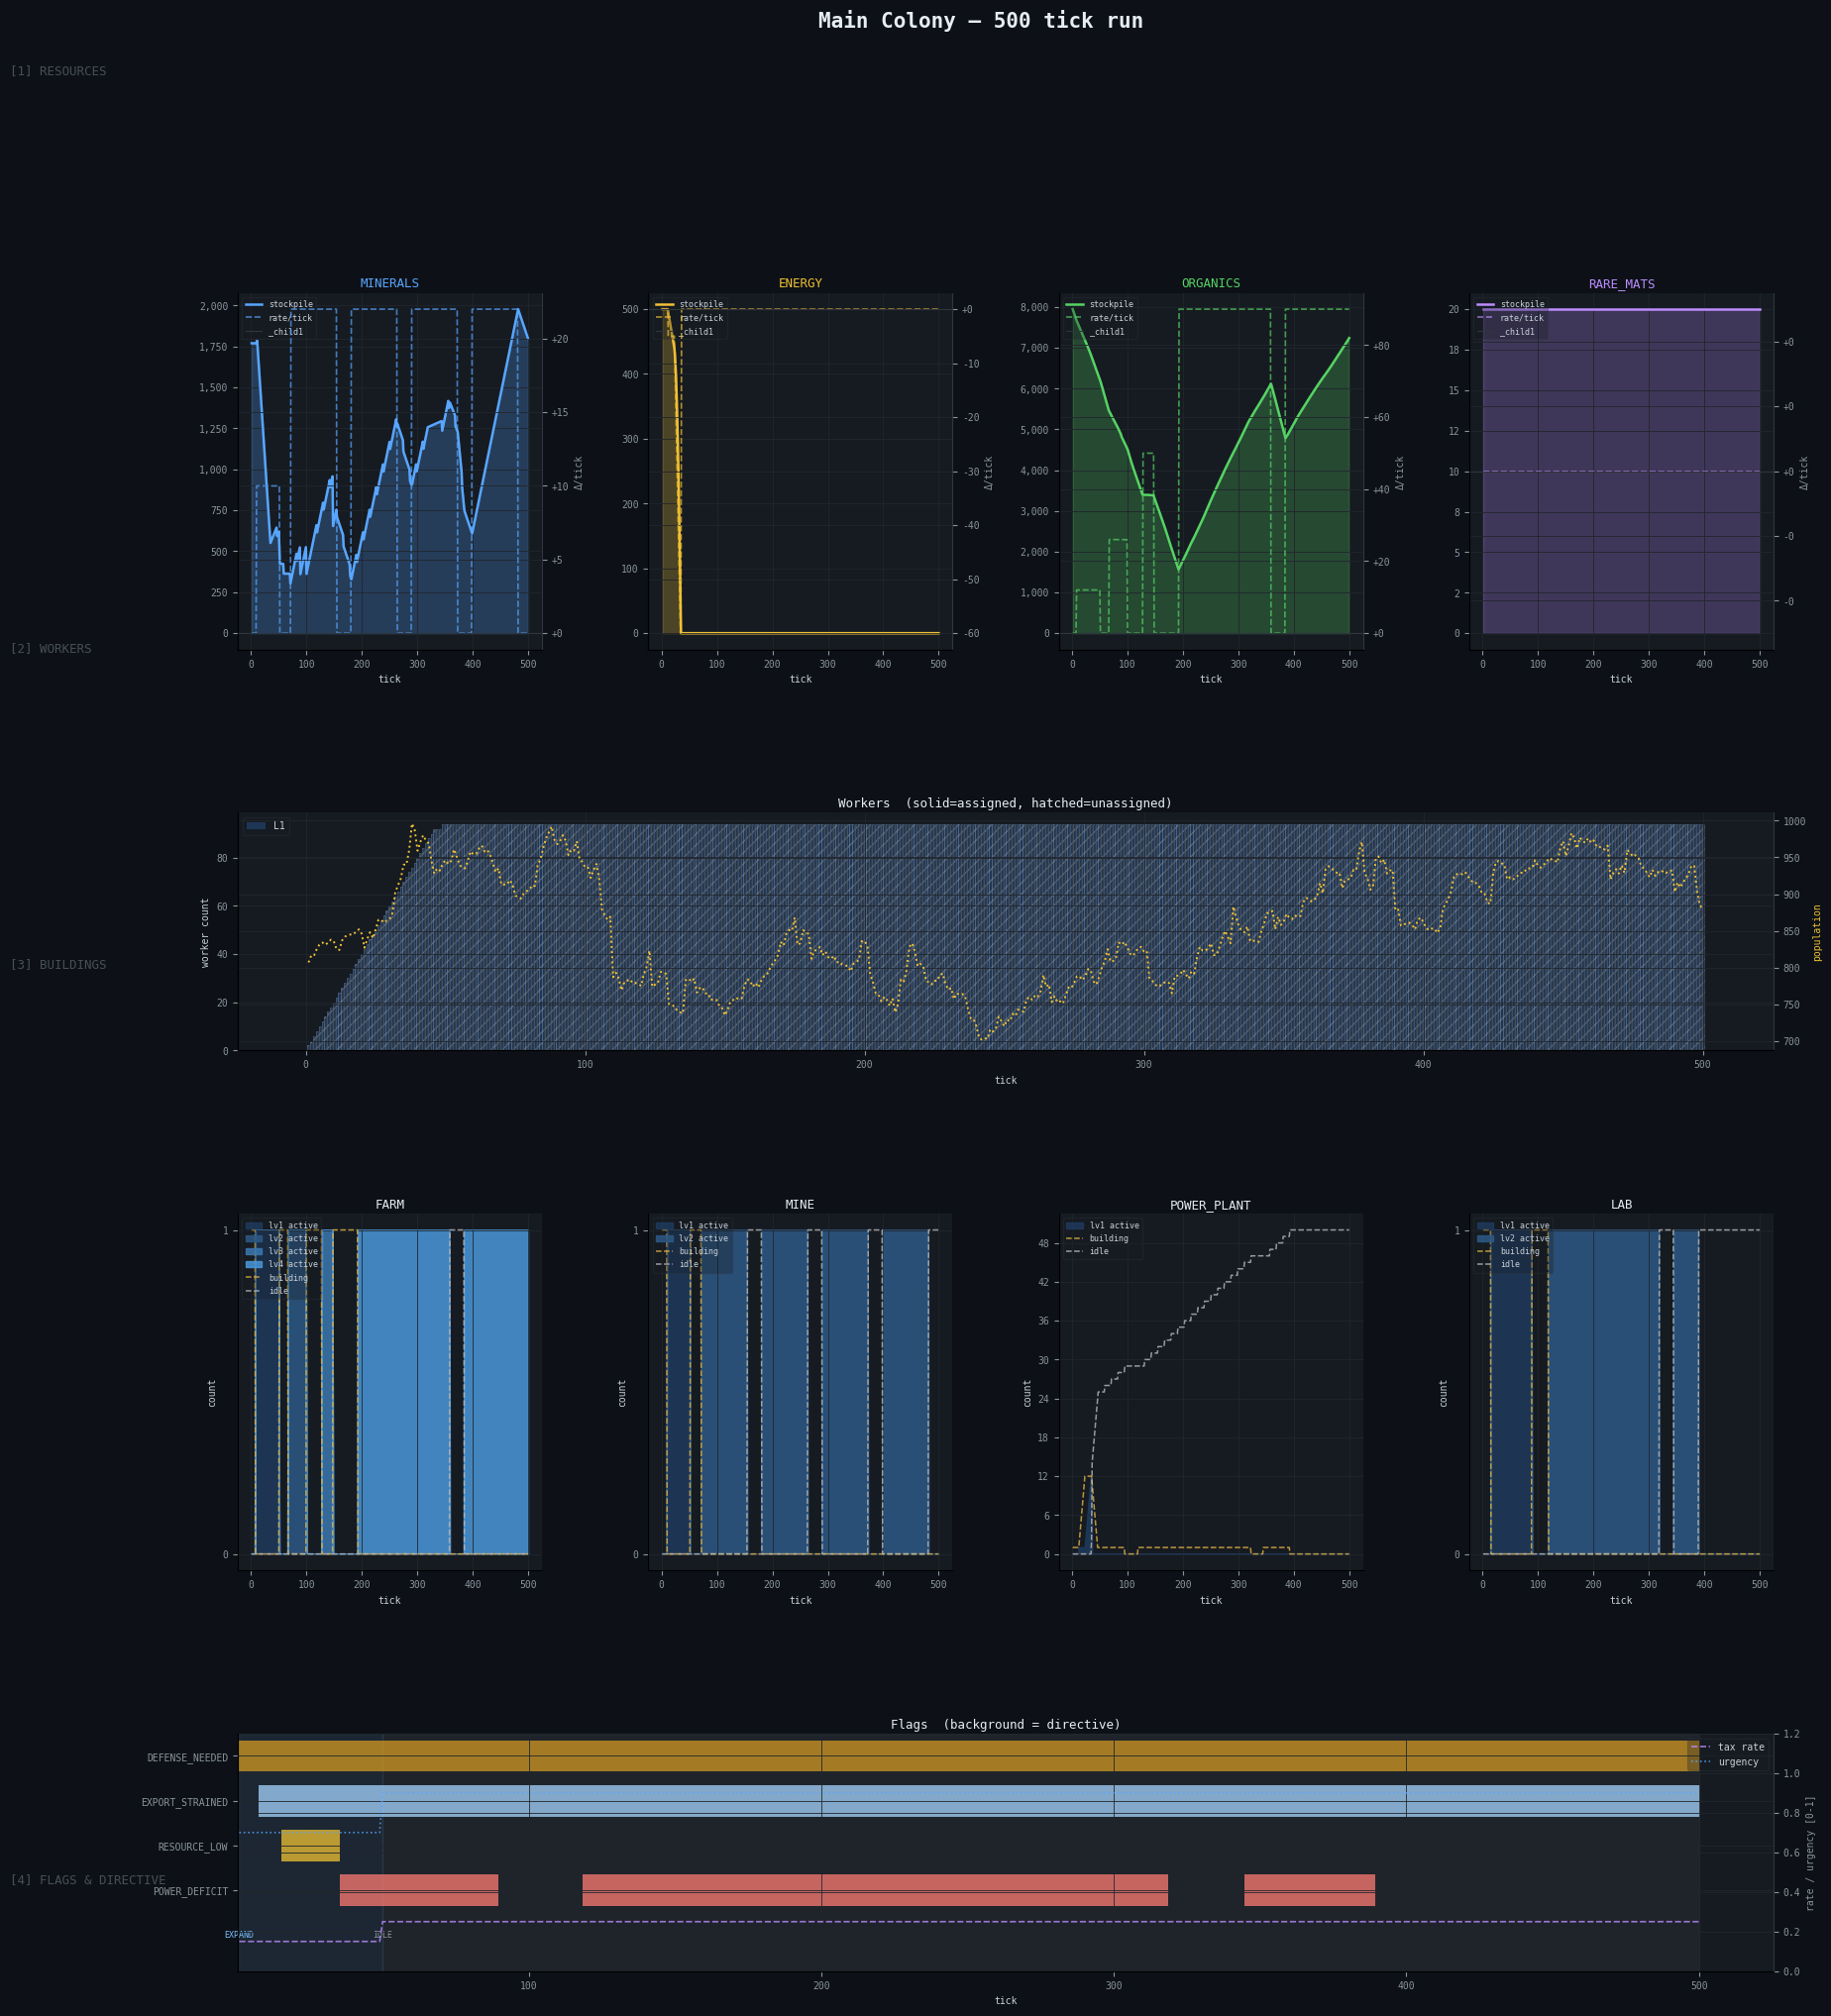

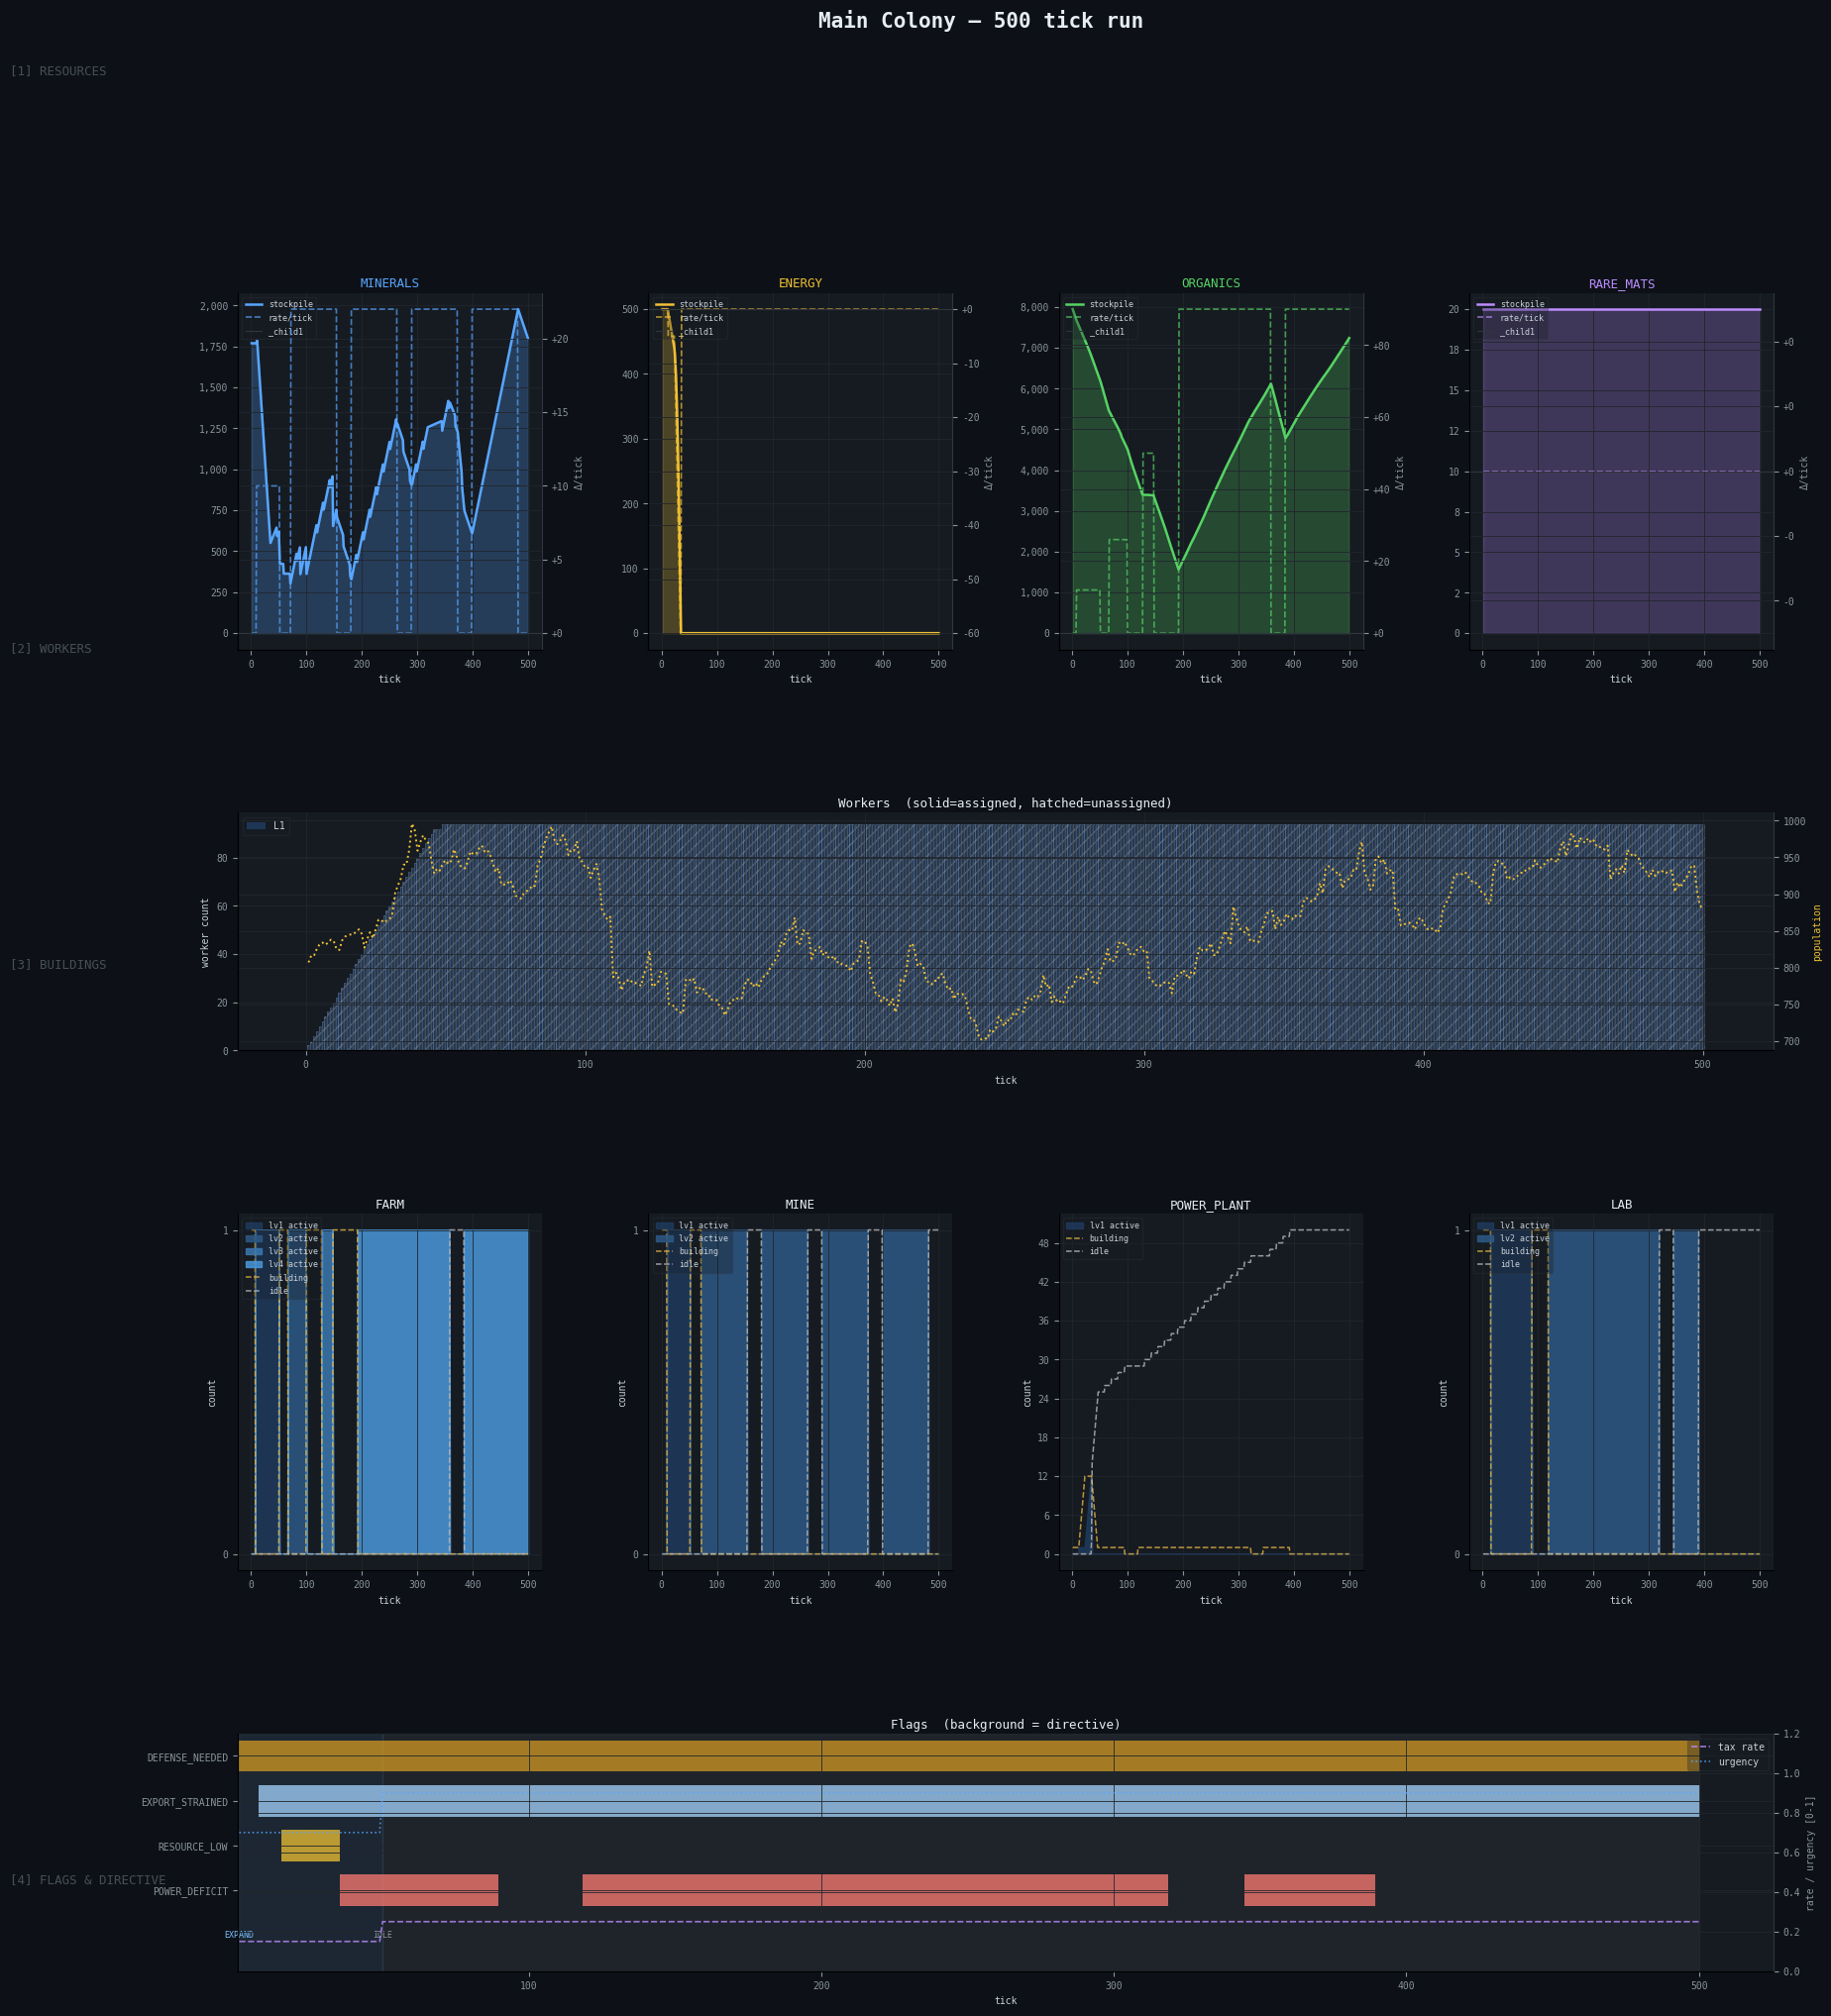

In [3]:
plot_history(history, title=f"{colony_name} — {tick_number} tick run", save_path=f"run_{tick_number}ticks.png")

In [8]:
# print the number of workers of each level in the home colony
print(f"Workers in {home.name}:")
for level in range(1,6):
    print(f"  Level {level}: {len(faction.colonies[0].workers_at_level(level))}")

Workers in Main Colony:
  Level 1: 94
  Level 2: 0
  Level 3: 0
  Level 4: 0
  Level 5: 0
